C:\Users\User\AppData\Local\Temp\ipykernel_31528\366225620.py:45: RuntimeWarning: divide by zero encountered in log
  loss_newton = -(1/m) * np.sum(y.reshape(-1, 1) * np.log(predictions_newton) + (1 - y.reshape(-1, 1)) * np.log(1 - predictions_newton))
C:\Users\User\AppData\Local\Temp\ipykernel_31528\366225620.py:45: RuntimeWarning: invalid value encountered in multiply
  loss_newton = -(1/m) * np.sum(y.reshape(-1, 1) * np.log(predictions_newton) + (1 - y.reshape(-1, 1)) * np.log(1 - predictions_newton))


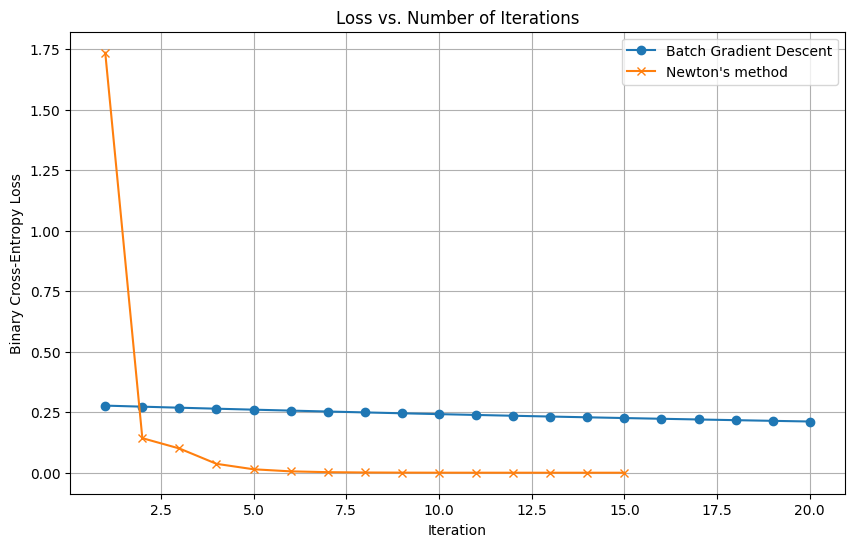

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Generate the data
centers = [[-5, 0], [5, 1.5]]
X, y = make_blobs(n_samples=2000, centers=centers, random_state=5)
transformation = [[0.5, 0.5], [-0.5, 1.5]]
X = np.dot(X, transformation)

# Add a bias (intercept) term to X
X_b = np.c_[np.ones((X.shape[0], 1)), X]

# Parameters
learning_rate = 0.01
n_iterations = 20
m = X_b.shape[0]

# Initialize weights
np.random.seed(42)
theta_gd = np.random.randn(X_b.shape[1], 1)
theta_newton = np.random.randn(X_b.shape[1], 1)

# Store losses for plotting
losses_gd = []
losses_newton = []

# Loop for both algorithms
for iteration in range(n_iterations):
    # Batch Gradient Descent
    logits_gd = X_b @ theta_gd
    predictions_gd = 1 / (1 + np.exp(-logits_gd))
    gradient_gd = (1/m) * X_b.T @ (predictions_gd - y.reshape(-1, 1))
    theta_gd -= learning_rate * gradient_gd
    loss_gd = -(1/m) * np.sum(y.reshape(-1, 1) * np.log(predictions_gd) + (1 - y.reshape(-1, 1)) * np.log(1 - predictions_gd))
    losses_gd.append(loss_gd)

    # Newton's Method
    logits_newton = X_b @ theta_newton
    predictions_newton = 1 / (1 + np.exp(-logits_newton))
    gradient_newton = (1/m) * X_b.T @ (predictions_newton - y.reshape(-1, 1))
    R = np.diag(predictions_newton.flatten() * (1 - predictions_newton.flatten()))
    hessian = (1/m) * X_b.T @ R @ X_b
    theta_newton -= np.linalg.inv(hessian) @ gradient_newton
    loss_newton = -(1/m) * np.sum(y.reshape(-1, 1) * np.log(predictions_newton) + (1 - y.reshape(-1, 1)) * np.log(1 - predictions_newton))
    losses_newton.append(loss_newton)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(range(1, n_iterations + 1), losses_gd, label='Batch Gradient Descent', marker='o')
plt.plot(range(1, n_iterations + 1), losses_newton, label="Newton's method", marker='x')
plt.title("Loss vs. Number of Iterations")
plt.xlabel("Iteration")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
import numpy as np

# Re-use X_b and y from previous block
n_iterations = 20
m = X_b.shape[0]

# Initialize weights for Newton's method
np.random.seed(42)
theta_newton = np.random.randn(X_b.shape[1], 1)

# Store loss for plotting
losses_newton = []

# Newton's Method
for iteration in range(n_iterations):
    logits = X_b @ theta_newton
    predictions = 1 / (1 + np.exp(-logits))
    
    # Calculate Gradient
    gradient = (1/m) * X_b.T @ (predictions - y.reshape(-1, 1))
    
    # Calculate Hessian Matrix
    R = np.diag(predictions.flatten() * (1 - predictions.flatten()))
    hessian = (1/m) * X_b.T @ R @ X_b
    
    # Update weights using the Newton step
    theta_newton -= np.linalg.inv(hessian) @ gradient
    
    # Correct loss calculation
    loss = -(1/m) * np.sum(y.reshape(-1, 1) * np.log(predictions) + (1 - y.reshape(-1, 1)) * np.log(1 - predictions))
    losses_newton.append(loss)

print("Final weights (Newton's Method):", theta_newton.flatten())

Final weights (Newton's Method): [-3.11618904 10.98878568  4.69348138]


C:\Users\User\AppData\Local\Temp\ipykernel_31528\903481334.py:30: RuntimeWarning: divide by zero encountered in log
  loss = -(1/m) * np.sum(y.reshape(-1, 1) * np.log(predictions) + (1 - y.reshape(-1, 1)) * np.log(1 - predictions))
C:\Users\User\AppData\Local\Temp\ipykernel_31528\903481334.py:30: RuntimeWarning: invalid value encountered in multiply
  loss = -(1/m) * np.sum(y.reshape(-1, 1) * np.log(predictions) + (1 - y.reshape(-1, 1)) * np.log(1 - predictions))


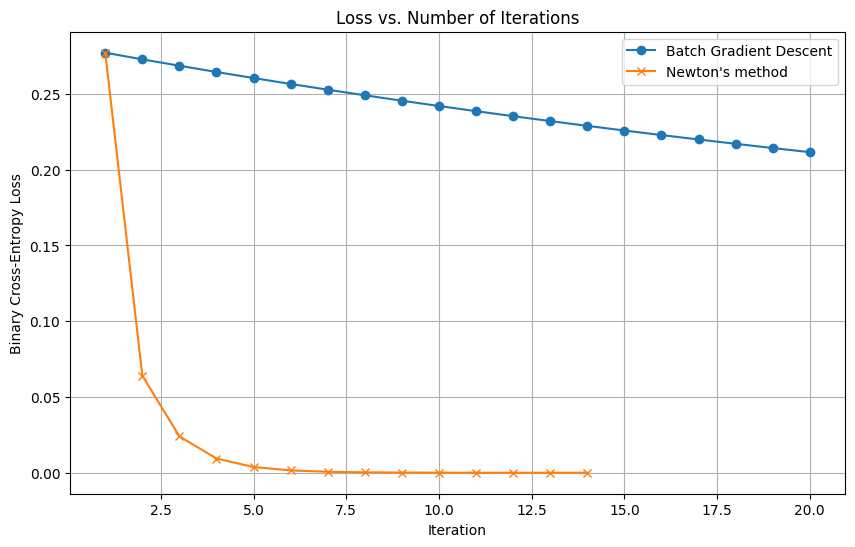

In [23]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 21), losses_gd, label='Batch Gradient Descent', marker='o')
plt.plot(range(1, 21), losses_newton, label="Newton's method", marker='x')
plt.title("Loss vs. Number of Iterations")
plt.xlabel("Iteration")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.grid(True)
plt.show()